# Lab: Stats Unit

### Import necessary libraries

In [1]:
import pandas as pd
from scipy.stats import ttest_ind, chisquare, mannwhitneyu, f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt

### Step 1: Read mortality.csv

In [2]:
mortality_data = pd.read_csv("mortality.csv")

In [3]:
mortality_data.head()

,Year,Age Group,Death Rate
0,1900,1-4 Years,1983.8
1,1901,1-4 Years,1695.0
2,1902,1-4 Years,1655.7
3,1903,1-4 Years,1542.1
4,1904,1-4 Years,1591.5


In [4]:
print(mortality_data.columns)

Index(['Year', 'Age Group', 'Death Rate'], dtype='object')


### Step 2: Select the mortality rates for the '5-9 Years' and '10-14 Years' age groups and assign these each to a new variable.

In [5]:
# Select the mortality rates for the '5-9 Years' and '10-14 Years' age groups
mortality_5_9 = mortality_data[mortality_data['Age Group'] == '5-9 Years']['Death Rate']
mortality_10_14 = mortality_data[mortality_data['Age Group'] == '10-14 Years']['Death Rate']

### Step 3: Run a t-test to see if these are significantly different

In [6]:
# Run a t-test
t_stat, p_value = ttest_ind(mortality_5_9, mortality_10_14)
if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference between the mortality rates of 5-9 years and 10-14 years age groups.")
else:
    print("Accept the null hypothesis. There is no significant difference between the mortality rates of 5-9 years and 10-14 years age groups.")


Accept the null hypothesis. There is no significant difference between the mortality rates of 5-9 years and 10-14 years age groups.


### Step 4: Make a histogram of the 5-9 year old age group to see if it looks normally distributed (bell-curve shaped)

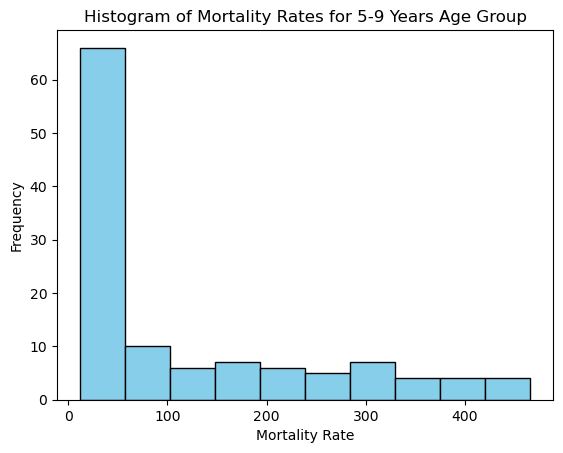

In [7]:
# Make a histogram of the 5-9 year old age group
plt.hist(mortality_5_9, bins=10, color='skyblue', edgecolor='black')
plt.title('Histogram of Mortality Rates for 5-9 Years Age Group')
plt.xlabel('Mortality Rate')
plt.ylabel('Frequency')
plt.show()

### Step 5: Run a non-parametric Mann Whitney U Test to see if you get a different result than the t-test

In [8]:
# Run a non-parametric Mann Whitney U Test
u_stat, p_value_mannwhitneyu = mannwhitneyu(mortality_5_9, mortality_10_14)
if p_value_mannwhitneyu < 0.05:
    print("Reject the null hypothesis. There is a significant difference between the mortality rates of 5-9 years and 10-14 years age groups.")
else:
    print("Accept the null hypothesis. There is no significant difference between the mortality rates of 5-9 years and 10-14 years age groups.")

Accept the null hypothesis. There is no significant difference between the mortality rates of 5-9 years and 10-14 years age groups.


### Step 6: Select the mortality rates for the 15-19 year old age group and assign it to a new variable

In [9]:
# Select the mortality rates for the 15-19 year old age group
mortality_15_19 = mortality_data[mortality_data['Age Group'] == '15-19 Years']['Death Rate']

### Step 7: Use all three groups and run an ANOVA to check if there are any differences between these groups

In [10]:
f_stat, p_value_anova = f_oneway(mortality_5_9, mortality_10_14, mortality_15_19)
# Write a comment indicating whether there are any differences between these groups
if p_value_anova < 0.05:
    print("Reject the null hypothesis. There are significant differences between the mortality rates of the age groups.")
else:
    print("Accept the null hypothesis. There are no significant differences between the mortality rates of the age groups.")

Reject the null hypothesis. There are significant differences between the mortality rates of the age groups.


### Step 8: We rolled a six-sided die 60 times, and got some weird results. Use this data to run a chi-squared test to see if we reject the null hypothesis that the frequency counts for each face of the die conform to the expected uniform distribution.

In [11]:
# Data for chi-squared test
observed = [8, 8, 8, 8, 8, 20]
expected = [10, 10, 10, 10, 10, 10]

In [12]:
# Run a chi-squared test
chi_stat, p_value_chi = chisquare(observed, expected)
# Write a comment indicating whether we reject the null hypothesis
if p_value_chi < 0.05:
    print("Reject the null hypothesis. The frequency counts for each face of the die do not conform to the expected uniform distribution.")
else:
    print("Accept the null hypothesis. The frequency counts for each face of the die conform to the expected uniform distribution.")

Reject the null hypothesis. The frequency counts for each face of the die do not conform to the expected uniform distribution.


### 1. Select the Years for the 15-19 Years age group and assign it to a variable named 'x'

In [13]:
# Select the Years for the 15-19 Years age group
x = mortality_data['Year']

### 2. Select the DeathRate for the 15-19 Years age group and assign it to a variable named 'y'

In [14]:
# Select the DeathRate for the 15-19 Years age group
y = mortality_data['Death Rate']

### 3. Use the OLS model from Chapter 10's lecture notebook to test whether there is a linear relationship between Year and DeathRate for the 15-19 year old age group in the mortality data.

In [15]:
# Add a constant term to the predictor variable x
x = sm.add_constant(x)

In [16]:
# Use the OLS model to test for linear relationship
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Death Rate   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     298.8
Date:                Wed, 24 Apr 2024   Prob (F-statistic):           2.86e-52
Time:                        22:32:02   Log-Likelihood:                -3262.7
No. Observations:                 476   AIC:                             6529.
Df Residuals:                     474   BIC:                             6538.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.058e+04    600.994     17.604      0.0